In [24]:
import sys
print(sys.executable)

%pip install -U pip
%pip install geopandas pyproj shapely fiona pandas pyarrow matplotlib pandas scikit-learn

/Users/amandadu/Desktop/coding/grad-recruitment-case-ds-25/nordic-expansion-analysis/.venv311/bin/python
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


✅ df_age_national head:
   year  ald0_5  ald5_10  ald10_15  ald15_20  ald20_25  ald25_30  ald30_35  \
0  2015  585997   588192    541696    521979    655742    680076    617522   
1  2016  596980   600491    563286    529060    638754    709693    638765   
2  2017  601968   612062    580091    544462    616403    732148    660660   
3  2018  603863   619067    595158    559067    596878    739933    688429   
4  2019  601265   623693    608618    568537    586749    738050    714129   

   ald35_40  ald40_45  ...  ald55_60  ald60_65  ald65_70  ald70_75  ald75_80  \
0    606631    650012  ...    578593    557593    588268    510979    345561   
1    615540    646142  ...    580021    561440    572888    539338    356684   
2    626508    640173  ...    585026    563947    560363    555823    376289   
3    638360    634555  ...    597602    564492    549493    563127    400272   
4    648944    629306  ...    618918    567520    539641    560088    427812   

   ald80_85  ald85_90  ald

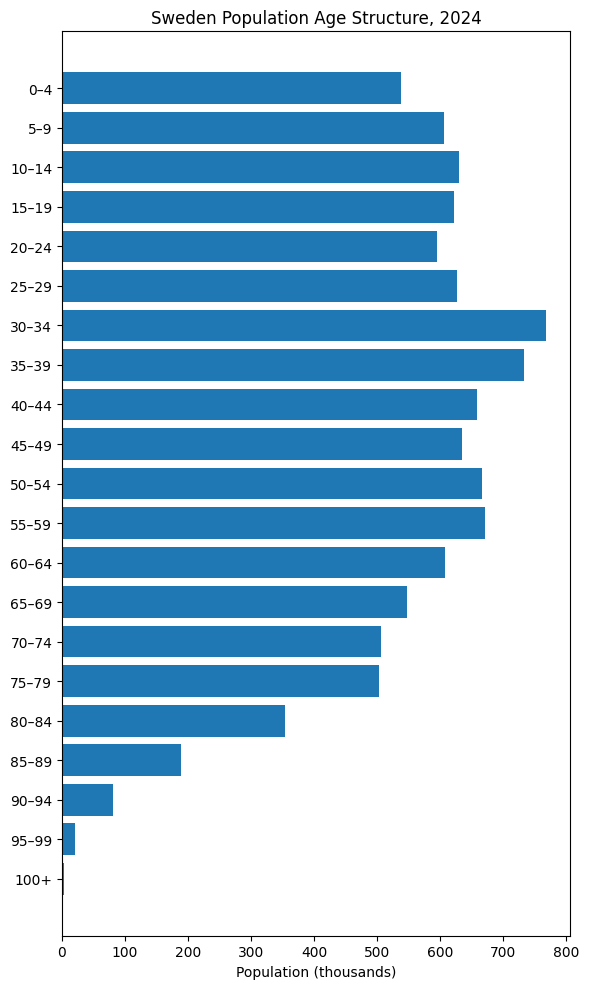

✅ df_age_sex_national head:
   year age_band     sex     population
0  2015      0–4  female  292760.037929
1  2016      0–4  female  297575.462257
2  2017      0–4  female  299541.718115
3  2018      0–4  female  300233.143723
4  2019      0–4  female  298688.859428
✅ saved: /Users/amandadu/Desktop/coding/grad-recruitment-case-ds-25/nordic-expansion-analysis/figures/population_pyramid_2024.png


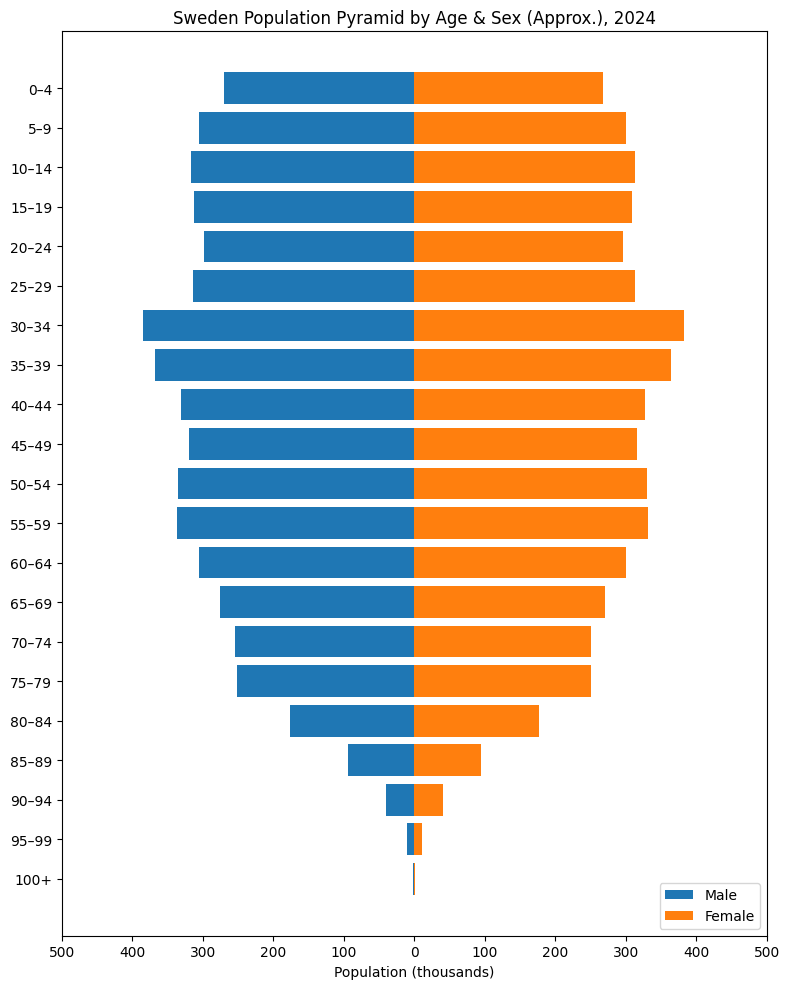

📊 Sweden Age Segment Shares (2024)
15–24: 11.53%
25–44: 26.39%
45–64: 24.41%
65+: 20.86%


In [25]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- 0. Load merged df_all ----------------
PROJECT_ROOT = Path(__file__).resolve().parents[1] if '__file__' in globals() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "geoparquet"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load 1 km grid data for 2015–2024 in one go
df_all = gpd.read_parquet(DATA_DIR / "befolkning_1km_2015_2024.parquet").copy()
df_all = df_all.set_crs(4326)

# If total_pop is missing, construct it from kvinna + man or beftotalt
if "total_pop" not in df_all.columns:
    if {"kvinna", "man"}.issubset(df_all.columns):
        df_all["total_pop"] = df_all["kvinna"] + df_all["man"]
    elif "beftotalt" in df_all.columns:
        df_all["total_pop"] = df_all["beftotalt"]
    else:
        raise ValueError("Cannot find total_pop / kvinna+man / beftotalt to represent total population")

YEARS = sorted(df_all["year"].unique())

# ---------------- 1. National age structure (sex-aggregated) ----------------

age_col_map = {
    "0–4":   "ald0_5",
    "5–9":   "ald5_10",
    "10–14": "ald10_15",
    "15–19": "ald15_20",
    "20–24": "ald20_25",
    "25–29": "ald25_30",
    "30–34": "ald30_35",
    "35–39": "ald35_40",
    "40–44": "ald40_45",
    "45–49": "ald45_50",
    "50–54": "ald50_55",
    "55–59": "ald55_60",
    "60–64": "ald60_65",
    "65–69": "ald65_70",
    "70–74": "ald70_75",
    "75–79": "ald75_80",
    "80–84": "ald80_85",
    "85–89": "ald85_90",
    "90–94": "ald90_95",
    "95–99": "ald95_100",
    "100+":  "ald100w",
}
age_labels = list(age_col_map.keys())
age_cols   = list(age_col_map.values())

# Aggregate national age-band population directly from df_all by year
df_age_national = (
    df_all
    .groupby("year")[age_cols]
    .sum()
    .reset_index()
)

print("✅ df_age_national head:")
print(df_age_national.head())

# ---------- 1.1 Single-year national age distribution bar chart (e.g., 2024) ----------
YEAR = 2024
row = df_age_national[df_age_national["year"] == YEAR].iloc[0]

values = [row[col] for col in age_cols]
values_in_1000 = np.array(values) / 1000

plt.figure(figsize=(6, 10))
plt.barh(age_labels, values_in_1000)
plt.xlabel("Population (thousands)")
plt.title(f"Sweden Population Age Structure, {YEAR}")
plt.gca().invert_yaxis()
plt.tight_layout()

out_path = FIG_DIR / f"age_structure_{YEAR}.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("✅ saved:", out_path)
plt.show()

# ---------------- 2. National age × sex structure (approximation) ----------------
# Idea: use each 1 km cell’s kvinna / total_pop as female_share,
# then split each age band into female / male using this share

if not {"kvinna", "man"}.issubset(df_all.columns):
    raise ValueError("Columns kvinna and man are required to approximate age × sex breakdown")

df = df_all.copy()
df["female_share"] = df["kvinna"] / df["total_pop"].replace(0, np.nan)

records = []

for age_label, col in age_col_map.items():
    if col not in df.columns:
        raise ValueError(f"Missing age column: {col}")
    tmp = df[["year", "total_pop", "kvinna", "man", col]].copy()

    # Approximate female / male counts for this age band within each cell
    tmp["female_pop"] = tmp[col] * (tmp["kvinna"] / tmp["total_pop"].replace(0, np.nan))
    tmp["male_pop"]   = tmp[col] * (tmp["man"]    / tmp["total_pop"].replace(0, np.nan))

    # Aggregate to national totals by year
    agg = (
        tmp.groupby("year")[["female_pop", "male_pop"]]
           .sum()
           .reset_index()
    )
    agg["age_band"] = age_label
    records.append(agg)

df_age_sex_national = pd.concat(records, ignore_index=True)

# Reshape to long format: year, age_band, sex, population
df_age_sex_national = df_age_sex_national.melt(
    id_vars=["year", "age_band"],
    value_vars=["female_pop", "male_pop"],
    var_name="sex",
    value_name="population",
)
df_age_sex_national["sex"] = df_age_sex_national["sex"].map(
    {"female_pop": "female", "male_pop": "male"}
)

print("✅ df_age_sex_national head:")
print(df_age_sex_national.head())

# ---------------- 2.1 Population pyramid for 2024 ----------------
YEAR = 2024
sub = df_age_sex_national[df_age_sex_national["year"] == YEAR].copy()

male = (
    sub[sub["sex"] == "male"]
    .set_index("age_band")
    .loc[age_labels, "population"] / 1000
)
female = (
    sub[sub["sex"] == "female"]
    .set_index("age_band")
    .loc[age_labels, "population"] / 1000
)

# Negative values for male side to create mirrored pyramid
male_neg = -male.values
female_pos = female.values

plt.figure(figsize=(8, 10))
plt.barh(age_labels, male_neg, label="Male")
plt.barh(age_labels, female_pos, label="Female")

plt.title(f"Sweden Population Pyramid by Age & Sex (Approx.), {YEAR}")
plt.xlabel("Population (thousands)")

# Replace negative x-ticks with positive labels
xticks = plt.xticks()[0]
plt.xticks(xticks, [abs(int(x)) for x in xticks])

plt.legend(loc="lower right")
plt.gca().invert_yaxis()
plt.tight_layout()

out_path = FIG_DIR / f"population_pyramid_{YEAR}.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("✅ saved:", out_path)

plt.show()

# ---------------- 3. Compute 2024 shares of key age segments ----------------
total_pop_2024 = sub["population"].sum()

segment_map = {
    "15–24": ["15–19", "20–24"],
    "25–44": ["25–29", "30–34", "35–39", "40–44"],
    "45–64": ["45–49", "50–54", "55–59", "60–64"],
    "65+":   ["65–69", "70–74", "75–79", "80–84", "85–89", "90–94", "95–99", "100+"],
}

segment_results = {}
for seg, bands in segment_map.items():
    seg_pop = sub[sub["age_band"].isin(bands)]["population"].sum()
    seg_pct = seg_pop / total_pop_2024 * 100
    segment_results[seg] = seg_pct

print("📊 Sweden Age Segment Shares (2024)")
for seg, pct in segment_results.items():
    print(f"{seg}: {pct:.2f}%")


In [5]:
from pathlib import Path
import geopandas as gpd

DATA_DIR = PROJECT_ROOT / "data"/"geoparquet"
for year in range(2015, 2025):
    path = Path(DATA_DIR) / f"befolkning_1km_{year}.parquet"
    gdf = gpd.read_parquet(path)
    print(year, list(gdf.columns))


2015 ['objectid', 'rutid_inspire', 'rutid_scb', 'rutstorl', 'beftotalt', 'kvinna', 'man', 'ald0_5', 'ald5_10', 'ald10_15', 'ald15_20', 'ald20_25', 'ald25_30', 'ald30_35', 'ald35_40', 'ald40_45', 'ald45_50', 'ald50_55', 'ald55_60', 'ald60_65', 'ald65_70', 'ald70_75', 'ald75_80', 'ald80_85', 'ald85_90', 'ald90_95', 'ald95_100', 'ald100w', 'referenstid', 'geometry']
2016 ['objectid', 'rutid_inspire', 'rutid_scb', 'rutstorl', 'beftotalt', 'kvinna', 'man', 'ald0_5', 'ald5_10', 'ald10_15', 'ald15_20', 'ald20_25', 'ald25_30', 'ald30_35', 'ald35_40', 'ald40_45', 'ald45_50', 'ald50_55', 'ald55_60', 'ald60_65', 'ald65_70', 'ald70_75', 'ald75_80', 'ald80_85', 'ald85_90', 'ald90_95', 'ald95_100', 'ald100w', 'referenstid', 'geometry']
2017 ['objectid', 'rutid_inspire', 'rutid_scb', 'rutstorl', 'beftotalt', 'kvinna', 'man', 'ald0_5', 'ald5_10', 'ald10_15', 'ald15_20', 'ald20_25', 'ald25_30', 'ald30_35', 'ald35_40', 'ald40_45', 'ald45_50', 'ald50_55', 'ald55_60', 'ald60_65', 'ald65_70', 'ald70_75', '